## Dataset Link:- [Kaggle](https://www.kaggle.com/competitions/msk-redefining-cancer-treatment/data)

In [2]:
import pandas as pd

In [3]:
data_variant = pd.read_csv('training_variants')

In [4]:
print(data_variant)

        ID    Gene             Variation  Class
0        0  FAM58A  Truncating Mutations      1
1        1     CBL                 W802*      2
2        2     CBL                 Q249E      2
3        3     CBL                 N454D      3
4        4     CBL                 L399V      4
...    ...     ...                   ...    ...
3316  3316   RUNX1                 D171N      4
3317  3317   RUNX1                 A122*      1
3318  3318   RUNX1               Fusions      1
3319  3319   RUNX1                  R80C      4
3320  3320   RUNX1                  K83E      4

[3321 rows x 4 columns]


In [5]:
data_text = pd.read_csv('training_text', sep=r'\|\|', engine='python', names=["ID", "TEXT"], skiprows=1)

In [6]:
print(data_text)

        ID                                               TEXT
0        0  Cyclin-dependent kinases (CDKs) regulate a var...
1        1   Abstract Background  Non-small cell lung canc...
2        2   Abstract Background  Non-small cell lung canc...
3        3  Recent evidence has demonstrated that acquired...
4        4  Oncogenic mutations in the monomeric Casitas B...
...    ...                                                ...
3316  3316  Introduction  Myelodysplastic syndromes (MDS) ...
3317  3317  Introduction  Myelodysplastic syndromes (MDS) ...
3318  3318  The Runt-related transcription factor 1 gene (...
3319  3319  The RUNX1/AML1 gene is the most frequent targe...
3320  3320  The most frequent mutations associated with le...

[3321 rows x 2 columns]


### Dataset Explanation

**training_variants**
- Contains structured information about each genetic mutation.
- Columns:
  - `ID`: Unique identifier for each mutation.
  - `Gene`: Name of the gene where the mutation is found.
  - `Variation`: The specific change (mutation) in the gene.
  - `Class`: The effect category of the mutation (an integer from 1 to 9, which is the target to predict).

**training_text**
- Contains unstructured text data for each mutation.
- Columns:
  - `ID`: Matches the ID in `training_variants`.
  - `Text`: A detailed description (from medical literature) about the mutation, its context, and possible effects.

For each mutation (ID), you have both structured (gene, variation) and unstructured (text) information. The goal is to use all this information to predict the correct class (effect) of the mutation.

In [7]:
print(data_text.head())

   ID                                               TEXT
0   0  Cyclin-dependent kinases (CDKs) regulate a var...
1   1   Abstract Background  Non-small cell lung canc...
2   2   Abstract Background  Non-small cell lung canc...
3   3  Recent evidence has demonstrated that acquired...
4   4  Oncogenic mutations in the monomeric Casitas B...


In [8]:
print(data_variant.head())

   ID    Gene             Variation  Class
0   0  FAM58A  Truncating Mutations      1
1   1     CBL                 W802*      2
2   2     CBL                 Q249E      2
3   3     CBL                 N454D      3
4   4     CBL                 L399V      4


In [9]:
data_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3321 entries, 0 to 3320
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      3321 non-null   int64 
 1   TEXT    3316 non-null   object
dtypes: int64(1), object(1)
memory usage: 52.0+ KB


In [10]:
data_variant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3321 entries, 0 to 3320
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         3321 non-null   int64 
 1   Gene       3321 non-null   object
 2   Variation  3321 non-null   object
 3   Class      3321 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 103.9+ KB


In [11]:
data_text.describe()

,ID
count,3321.000000
mean,1660.000000
std,958.834449
min,0.000000
25%,830.000000
50%,1660.000000
75%,2490.000000
max,3320.000000


In [12]:
data_variant.describe()

,ID,Class
count,3321.000000,3321.000000
mean,1660.000000,4.365854
std,958.834449,2.309781
min,0.000000,1.000000
25%,830.000000,2.000000
50%,1660.000000,4.000000
75%,2490.000000,7.000000
max,3320.000000,9.000000


In [13]:
data_text.shape

(3321, 2)

In [14]:
data_variant.shape

(3321, 4)

In [15]:
data_text.value_counts()

ID    TEXT                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [16]:
data_variant.columns.tolist()

['ID', 'Gene', 'Variation', 'Class']

In [17]:
data_variant['Class'].value_counts()

Class
7    953
4    686
1    568
2    452
6    275
5    242
3     89
9     37
8     19
Name: count, dtype: int64

In [20]:
data_variant_merged = data_variant.merge(data_text, on = 'ID', how = 'left')

In [34]:
print(data_variant_merged)

        ID    Gene         Variation  Class  \
0     1057   EWSR1  EWSR1-FEV Fusion      2   
1      812   ERCC2             V536M      1   
2     2658   BRCA1              K50E      6   
3      809   ERCC2             R631C      1   
4      862    ABL1             F359C      2   
...    ...     ...               ...    ...   
3316  1095  MAP3K1            E1286V      5   
3317  1130     MET            D1010H      2   
3318  1294    HRAS              Q22K      2   
3319   860    ABL1             F317L      2   
3320  3174   RAB35             F161L      7   

                                                   TEXT  
0     As a result of chromosome translocations, the ...  
1     The increasing application of gene panels for ...  
2     Germline mutations of the breast cancer 1 (BRC...  
3     The increasing application of gene panels for ...  
4     For patients with chronic myeloid leukemia who...  
...                                                 ...  
3316  Langerhans cell histioc

In [23]:
# Find the maximum class count
max_count = data_variant_merged['Class'].value_counts().max()
max_count

np.int64(953)

In [27]:
from sklearn.utils import resample

# Oversample each class
balanced_list = []
for c in data_variant_merged['Class'].unique():
    class_subset = data_variant_merged[data_variant_merged['Class'] == c]
    class_oversampled = resample(class_subset, replace=True, n_samples=max_count, random_state=42)
    balanced_list.append(class_oversampled)

data_variant_balanced = pd.concat(balanced_list)

data_variant_balanced

,ID,Gene,Variation,Class,TEXT
468,468,TP53,K291Q,1,Tumor suppressor p53-dependent apoptosis is th...
2403,2403,NF1,Truncating Mutations,1,Ras (p21'as) interacts directly with the catal...
1160,1160,FAT1,P4309A,1,Chromosome 4q35 is frequently lost in numerous...
472,472,TP53,A347T,1,The tumor suppressor protein p53 is a transcri...
411,411,TP53,S241F,1,The p53 gene is the most commonly mutated targ...
...,...,...,...,...,...
1082,1082,EZH2,Y646F,9,"EZH2, the catalytic subunit of the PRC2 comple..."
1373,1373,AKT2,G161V,9,The serine–threonine kinase AKT regulates prol...
1769,1769,IDH2,R172K,9,The somatic mutations in cytosolic isocitrate ...
1373,1373,AKT2,G161V,9,The serine–threonine kinase AKT regulates prol...


In [32]:
# Shuffle the balanced data
data_variant_balanced = data_variant_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

data_variant_balanced

,ID,Gene,Variation,Class,TEXT
0,3051,KIT,V654A,7,Most GIST patients develop clinical resistance...
1,129,SF3B1,K666T,9,The RNA maturation is an important and complex...
2,524,TP53,G356A,6,"The tumor suppressor p53, a 393-amino acid tra..."
3,2274,BCOR,BCOR-RARA Fusion,8,The majority of acute promyelocytic leukemia (...
4,121,SF3B1,K700R,8,The RNA maturation is an important and complex...
...,...,...,...,...,...
8572,1756,IDH1,R132Q,8,Current genomic and biochemical analysis revea...
8573,122,SF3B1,R625C,9,The RNA maturation is an important and complex...
8574,1325,MLH1,V384D,5,Abstract We characterized four pancreatic carc...
8575,395,TP53,G245D,1,TP53 is the most commonly mutated gene in head...


In [35]:
# Split back into variants and text files
training_variants_balanced = data_variant_balanced[['ID', 'Gene', 'Variation', 'Class']]
training_text_balanced = data_variant_balanced[['ID', 'TEXT']]

In [36]:
training_text_balanced

,ID,TEXT
0,3051,Most GIST patients develop clinical resistance...
1,129,The RNA maturation is an important and complex...
2,524,"The tumor suppressor p53, a 393-amino acid tra..."
3,2274,The majority of acute promyelocytic leukemia (...
4,121,The RNA maturation is an important and complex...
...,...,...
8572,1756,Current genomic and biochemical analysis revea...
8573,122,The RNA maturation is an important and complex...
8574,1325,Abstract We characterized four pancreatic carc...
8575,395,TP53 is the most commonly mutated gene in head...


In [37]:
training_variants_balanced

,ID,Gene,Variation,Class
0,3051,KIT,V654A,7
1,129,SF3B1,K666T,9
2,524,TP53,G356A,6
3,2274,BCOR,BCOR-RARA Fusion,8
4,121,SF3B1,K700R,8
...,...,...,...,...
8572,1756,IDH1,R132Q,8
8573,122,SF3B1,R625C,9
8574,1325,MLH1,V384D,5
8575,395,TP53,G245D,1


In [38]:
# Save to new files
training_text_balanced.to_csv('training_text_balanced.csv', index=False, sep='\t', header=True)
training_variants_balanced.to_csv('training_variants_balanced.csv', index=False)

In [42]:
training_test_balanced_csv = pd.read_csv('training_text_balanced.csv',sep='\t')
training_test_balanced_csv['TEXT'].value_counts()

TEXT
Mutations in BRCA1 and BRCA2 account for the majority of hereditary breast and ovarian cancers, and therefore sequence analysis of both genes is routinely conducted in patients with early-onset breast cancer. Besides mutations that clearly abolish protein function or are known to increase cancer risk, a large number of sequence variants of uncertain signifi cance (VUS) have been identifi ed. Although several functional assays for BRCA1 VUSs have been described, thus far it has not been possible to conduct a high-throughput analysis in the context of the full-length protein. We have developed a relatively fast and easy cDNA-based functional assay to classify BRCA1 VUSs based on their ability to functionally complement BRCA1-defi cient mouse embryonic stem cells. Using this assay, we have analyzed 74 unclassifi ed BRCA1 missense mutants for which all predicted pathogenic variants are confi ned to the BRCA1 RING and BRCT domains.  SIGNIFICANCE: BRCA1 VUSs are frequently found in pati

In [40]:
training_variants_balanced_csv = pd.read_csv('training_variants_balanced.csv')
training_variants_balanced_csv['Class'].value_counts()

Class
7    953
9    953
6    953
8    953
1    953
5    953
3    953
2    953
4    953
Name: count, dtype: int64

In [45]:
# Top 5 most common mutation types
top_variations = data_variant['Variation'].value_counts().head(5)
print("Top 5 mutation types:\n", top_variations)

Top 5 mutation types:
 Variation
Truncating Mutations    93
Deletion                74
Amplification           71
Fusions                 34
Overexpression           6
Name: count, dtype: int64


In [47]:
# Top 5 most common genes
top_genes = data_variant['Gene'].value_counts().head(5)
print("Top 5 genes:\n", top_genes)

Top 5 genes:
 Gene
BRCA1    264
TP53     163
EGFR     141
PTEN     126
BRCA2    125
Name: count, dtype: int64


### Insights from Top Genes and Mutation Types

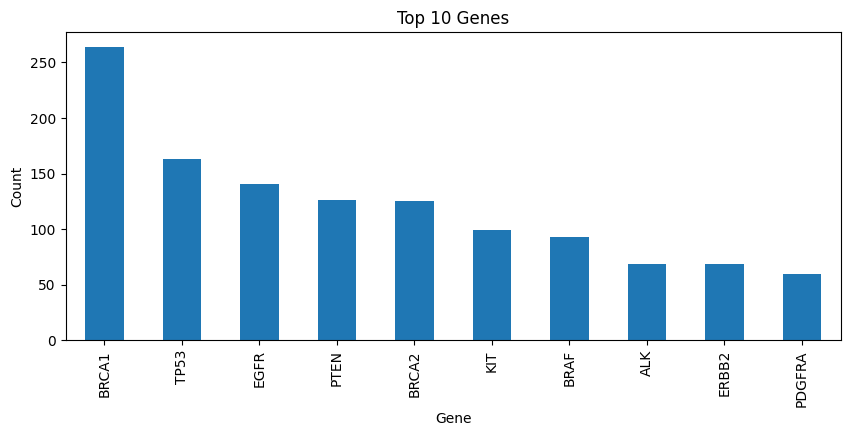

In [53]:
import matplotlib.pyplot as plt

# Top 10 genes
plt.figure(figsize=(10,4))
data_variant['Gene'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Gene')
plt.ylabel('Count')
plt.title('Top 10 Genes')
plt.show()

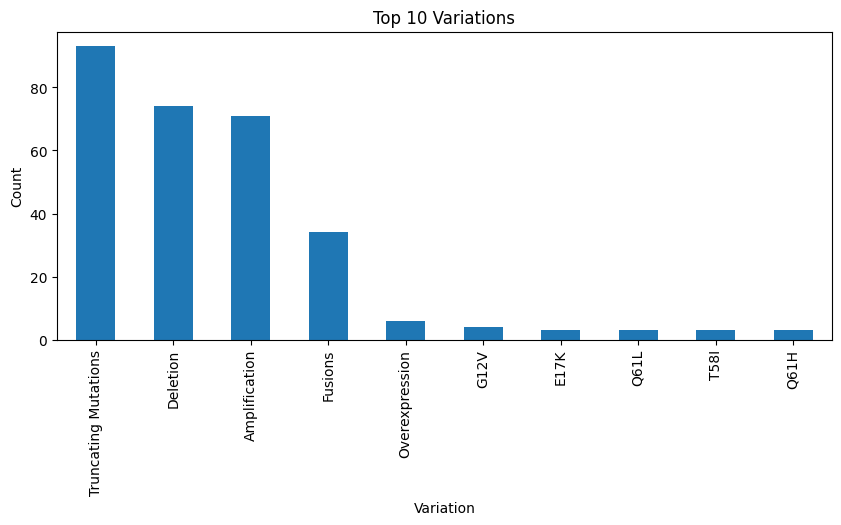

In [54]:
import matplotlib.pyplot as plt

# Top 10 variations
plt.figure(figsize=(10,4))
data_variant['Variation'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Variation')
plt.ylabel('Count')
plt.title('Top 10 Variations')
plt.show()

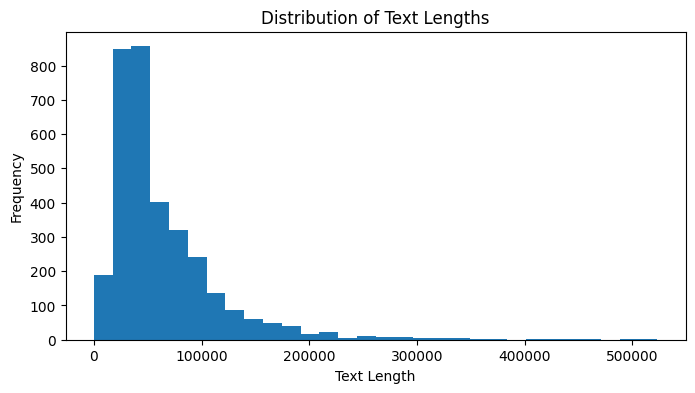

In [58]:
plt.figure(figsize=(8,4))
data_text['Text_Length'] = data_text['TEXT'].fillna('').apply(len)
plt.hist(data_text['Text_Length'], bins=30)
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths')
plt.show()